#
NOTE: If you have the `tut3-model.pt` file, Set below's `do_not_retrain=True` so it doesn't retrain.

In [205]:
do_not_retrain=True

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import spacy
import datasets
import torchtext
import tqdm
import evaluate
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# New libraries for stress testing and training on bigger dataset
import pandas as pd
from pyarrow import Table
from pyarrow import array as pa_array
from random import sample

In [2]:
seed = 1234

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [3]:
dataset = datasets.load_dataset("bentrevett/multi30k")
dataset

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

In [4]:
train_data, valid_data, test_data = (
    dataset["train"],
    dataset["validation"],
    dataset["test"],
)

In [5]:
en_nlp = spacy.load("en_core_web_sm")
de_nlp = spacy.load("de_core_news_sm")

In [6]:
def tokenize_example(example, en_nlp, de_nlp, max_length, lower, sos_token, eos_token):
    en_tokens = [token.text for token in en_nlp.tokenizer(example["en"])][:max_length]
    de_tokens = [token.text for token in de_nlp.tokenizer(example["de"])][:max_length]
    if lower:
        en_tokens = [token.lower() for token in en_tokens]
        de_tokens = [token.lower() for token in de_tokens]
    en_tokens = [sos_token] + en_tokens + [eos_token]
    de_tokens = [sos_token] + de_tokens + [eos_token]
    return {"en_tokens": en_tokens, "de_tokens": de_tokens}

In [7]:
max_length = 1_000
lower = True
sos_token = "<sos>"
eos_token = "<eos>"

fn_kwargs = {
    "en_nlp": en_nlp,
    "de_nlp": de_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

train_data = train_data.map(tokenize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(tokenize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(tokenize_example, fn_kwargs=fn_kwargs)

In [8]:
# With tortext >0.9, torchtext.vocab.build_vocab_from_iterator must be imported instead of called directly
from torchtext.vocab import build_vocab_from_iterator

/home/pikasan/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/home/pikasan/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [9]:
min_freq = 2
unk_token = "<unk>"
pad_token = "<pad>"

special_tokens = [
    unk_token,
    pad_token,
    sos_token,
    eos_token,
]

en_vocab = build_vocab_from_iterator(
    train_data["en_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

de_vocab = build_vocab_from_iterator(
    train_data["de_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

In [10]:
assert en_vocab[unk_token] == de_vocab[unk_token]
assert en_vocab[pad_token] == de_vocab[pad_token]

unk_index = en_vocab[unk_token]
pad_index = en_vocab[pad_token]

In [11]:
en_vocab.set_default_index(unk_index)
de_vocab.set_default_index(unk_index)

In [12]:
def numericalize_example(example, en_vocab, de_vocab):
    en_ids = en_vocab.lookup_indices(example["en_tokens"])
    de_ids = de_vocab.lookup_indices(example["de_tokens"])
    return {"en_ids": en_ids, "de_ids": de_ids}

In [13]:
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}

train_data = train_data.map(numericalize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(numericalize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(numericalize_example, fn_kwargs=fn_kwargs)

In [14]:
data_type = "torch"
format_columns = ["en_ids", "de_ids"]

train_data = train_data.with_format(
    type=data_type, columns=format_columns, output_all_columns=True
)

valid_data = valid_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

test_data = test_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [15]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_en_ids = [example["en_ids"] for example in batch]
        batch_de_ids = [example["de_ids"] for example in batch]
        batch_en_ids = nn.utils.rnn.pad_sequence(batch_en_ids, padding_value=pad_index)
        batch_de_ids = nn.utils.rnn.pad_sequence(batch_de_ids, padding_value=pad_index)
        batch = {
            "en_ids": batch_en_ids,
            "de_ids": batch_de_ids,
        }
        return batch

    return collate_fn

In [16]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader

In [17]:
batch_size = 128

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

In [18]:
class Encoder(nn.Module):
    def __init__(
        self, input_dim, embedding_dim, encoder_hidden_dim, decoder_hidden_dim, dropout
    ):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, encoder_hidden_dim, bidirectional=True)
        self.fc = nn.Linear(encoder_hidden_dim * 2, decoder_hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src length, batch size]
        embedded = self.dropout(self.embedding(src))
        # embedded = [src length, batch size, embedding dim]
        outputs, hidden = self.rnn(embedded)
        # outputs = [src length, batch size, hidden dim * n directions]
        # hidden = [n layers * n directions, batch size, hidden dim]
        # hidden is stacked [forward_1, backward_1, forward_2, backward_2, ...]
        # outputs are always from the last layer
        # hidden [-2, :, : ] is the last of the forwards RNN
        # hidden [-1, :, : ] is the last of the backwards RNN
        # initial decoder hidden is final hidden state of the forwards and backwards
        # encoder RNNs fed through a linear layer
        hidden = torch.tanh(
            self.fc(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1))
        )
        # outputs = [src length, batch size, encoder hidden dim * 2]
        # hidden = [batch size, decoder hidden dim]
        return outputs, hidden

In [19]:
class Attention(nn.Module):
    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):
        super().__init__()
        self.attn_fc = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim, decoder_hidden_dim
        )
        self.v_fc = nn.Linear(decoder_hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden = [batch size, decoder hidden dim]
        # encoder_outputs = [src length, batch size, encoder hidden dim * 2]
        batch_size = encoder_outputs.shape[1]
        src_length = encoder_outputs.shape[0]
        # repeat decoder hidden state src_length times
        hidden = hidden.unsqueeze(1).repeat(1, src_length, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # hidden = [batch size, src length, decoder hidden dim]
        # encoder_outputs = [batch size, src length, encoder hidden dim * 2]
        energy = torch.tanh(self.attn_fc(torch.cat((hidden, encoder_outputs), dim=2)))
        # energy = [batch size, src length, decoder hidden dim]
        attention = self.v_fc(energy).squeeze(2)
        # attention = [batch size, src length]
        return torch.softmax(attention, dim=1)

In [20]:
class Decoder(nn.Module):
    def __init__(
        self,
        output_dim,
        embedding_dim,
        encoder_hidden_dim,
        decoder_hidden_dim,
        dropout,
        attention,
    ):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.rnn = nn.GRU((encoder_hidden_dim * 2) + embedding_dim, decoder_hidden_dim)
        self.fc_out = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim + embedding_dim, output_dim
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input = [batch size]
        # hidden = [batch size, decoder hidden dim]
        # encoder_outputs = [src length, batch size, encoder hidden dim * 2]
        input = input.unsqueeze(0)
        # input = [1, batch size]
        embedded = self.dropout(self.embedding(input))
        # embedded = [1, batch size, embedding dim]
        a = self.attention(hidden, encoder_outputs)
        # a = [batch size, src length]
        a = a.unsqueeze(1)
        # a = [batch size, 1, src length]
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # encoder_outputs = [batch size, src length, encoder hidden dim * 2]
        weighted = torch.bmm(a, encoder_outputs)
        # weighted = [batch size, 1, encoder hidden dim * 2]
        weighted = weighted.permute(1, 0, 2)
        # weighted = [1, batch size, encoder hidden dim * 2]
        rnn_input = torch.cat((embedded, weighted), dim=2)
        # rnn_input = [1, batch size, (encoder hidden dim * 2) + embedding dim]
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        # output = [seq length, batch size, decoder hid dim * n directions]
        # hidden = [n layers * n directions, batch size, decoder hid dim]
        # seq len, n layers and n directions will always be 1 in this decoder, therefore:
        # output = [1, batch size, decoder hidden dim]
        # hidden = [1, batch size, decoder hidden dim]
        # this also means that output == hidden
        assert (output == hidden).all()
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        # prediction = [batch size, output dim]
        return prediction, hidden.squeeze(0), a.squeeze(1)

In [21]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio):
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        # teacher_forcing_ratio is probability to use teacher forcing
        # e.g. if teacher_forcing_ratio is 0.75 we use teacher forcing 75% of the time
        batch_size = src.shape[1]
        trg_length = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        # tensor to store decoder outputs
        outputs = torch.zeros(trg_length, batch_size, trg_vocab_size).to(self.device)
        # encoder_outputs is all hidden states of the input sequence, back and forwards
        # hidden is the final forward and backward hidden states, passed through a linear layer
        encoder_outputs, hidden = self.encoder(src)
        # outputs = [src length, batch size, encoder hidden dim * 2]
        # hidden = [batch size, decoder hidden dim]
        # first input to the decoder is the <sos> tokens
        input = trg[0, :]
        for t in range(1, trg_length):
            # insert input token embedding, previous hidden state and all encoder hidden states
            # receive output tensor (predictions) and new hidden state
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            # output = [batch size, output dim]
            # hidden = [n layers, batch size, decoder hidden dim]
            # place predictions in a tensor holding predictions for each token
            outputs[t] = output
            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio
            # get the highest predicted token from our predictions
            top1 = output.argmax(1)
            # if teacher forcing, use actual next token as next input
            # if not, use predicted token
            input = trg[t] if teacher_force else top1
            # input = [batch size]
        return outputs

In [22]:
input_dim = len(de_vocab)
output_dim = len(en_vocab)
encoder_embedding_dim = 256
decoder_embedding_dim = 256
encoder_hidden_dim = 512
decoder_hidden_dim = 512
encoder_dropout = 0.5
decoder_dropout = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

attention = Attention(encoder_hidden_dim, decoder_hidden_dim)

encoder = Encoder(
    input_dim,
    encoder_embedding_dim,
    encoder_hidden_dim,
    decoder_hidden_dim,
    encoder_dropout,
)

decoder = Decoder(
    output_dim,
    decoder_embedding_dim,
    encoder_hidden_dim,
    decoder_hidden_dim,
    decoder_dropout,
    attention,
)

model = Seq2Seq(encoder, decoder, device).to(device)

In [23]:
def init_weights(m):
    for name, param in m.named_parameters():
        if "weight" in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)


model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7853, 256)
    (rnn): GRU(256, 512, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn_fc): Linear(in_features=1536, out_features=512, bias=True)
      (v_fc): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(5893, 256)
    (rnn): GRU(1280, 512)
    (fc_out): Linear(in_features=1792, out_features=5893, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [24]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 20,518,405 trainable parameters


In [25]:
optimizer = optim.Adam(model.parameters())

In [26]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_index)

In [27]:
def train_fn(
    model, data_loader, optimizer, criterion, clip, teacher_forcing_ratio, device
):
    model.train()
    epoch_loss = 0
    for i, batch in enumerate(data_loader):
        src = batch["de_ids"].to(device)
        trg = batch["en_ids"].to(device)
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)
        # output = [trg length, batch size, trg vocab size]
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        # output = [(trg length - 1) * batch size, trg vocab size]
        trg = trg[1:].view(-1)
        # trg = [(trg length - 1) * batch size]
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [28]:
def evaluate_fn(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            src = batch["de_ids"].to(device)
            trg = batch["en_ids"].to(device)
            # src = [src length, batch size]
            # trg = [trg length, batch size]
            output = model(src, trg, 0)  # turn off teacher forcing
            # output = [trg length, batch size, trg vocab size]
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            # output = [(trg length - 1) * batch size, trg vocab size]
            trg = trg[1:].view(-1)
            # trg = [(trg length - 1) * batch size]
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [29]:
if not do_not_retrain:
    n_epochs = 10
    clip = 1.0
    teacher_forcing_ratio = 0.5
    
    best_valid_loss = float("inf")
    
    for epoch in tqdm.tqdm(range(n_epochs)):
        train_loss = train_fn(
            model,
            train_data_loader,
            optimizer,
            criterion,
            clip,
            teacher_forcing_ratio,
            device,
        )
        valid_loss = evaluate_fn(
            model,
            valid_data_loader,
            criterion,
            device,
        )
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), "tut3-model.pt")
        print(f"\tTrain Loss: {train_loss:7.3f} | Train PPL: {np.exp(train_loss):7.3f}")
        print(f"\tValid Loss: {valid_loss:7.3f} | Valid PPL: {np.exp(valid_loss):7.3f}")

 10%|████████▍                                                                           | 1/10 [00:50<07:30, 50.03s/it]

	Train Loss:   5.008 | Train PPL: 149.655
	Valid Loss:   4.781 | Valid PPL: 119.254


 20%|████████████████▊                                                                   | 2/10 [01:40<06:43, 50.40s/it]

	Train Loss:   4.159 | Train PPL:  63.995
	Valid Loss:   4.422 | Valid PPL:  83.230


 30%|█████████████████████████▏                                                          | 3/10 [02:30<05:49, 49.91s/it]

...

	Train Loss:   1.800 | Train PPL:   6.047
	Valid Loss:   3.356 | Valid PPL:  28.674


 90%|███████████████████████████████████████████████████████████████████████████▌        | 9/10 [07:23<00:48, 48.96s/it]

	Train Loss:   1.639 | Train PPL:   5.152
	Valid Loss:   3.334 | Valid PPL:  28.045


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [08:13<00:00, 49.31s/it]

	Train Loss:   1.492 | Train PPL:   4.445
	Valid Loss:   3.410 | Valid PPL:  30.276


In [30]:
model.load_state_dict(torch.load("tut3-model.pt"))

test_loss = evaluate_fn(model, test_data_loader, criterion, device)

print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

| Test Loss: 3.305 | Test PPL:  27.242 |


In [31]:
def translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
    max_output_length=25,
):
    model.eval()
    with torch.no_grad():
        if isinstance(sentence, str):
            de_tokens = [token.text for token in de_nlp.tokenizer(sentence)]
        else:
            de_tokens = [token for token in sentence]
        if lower:
            de_tokens = [token.lower() for token in de_tokens]
        de_tokens = [sos_token] + de_tokens + [eos_token]
        ids = de_vocab.lookup_indices(de_tokens)
        tensor = torch.LongTensor(ids).unsqueeze(-1).to(device)
        encoder_outputs, hidden = model.encoder(tensor)
        inputs = en_vocab.lookup_indices([sos_token])
        attentions = torch.zeros(max_output_length, 1, len(ids))
        for i in range(max_output_length):
            inputs_tensor = torch.LongTensor([inputs[-1]]).to(device)
            output, hidden, attention = model.decoder(
                inputs_tensor, hidden, encoder_outputs
            )
            attentions[i] = attention
            predicted_token = output.argmax(-1).item()
            inputs.append(predicted_token)
            if predicted_token == en_vocab[eos_token]:
                break
        en_tokens = en_vocab.lookup_tokens(inputs)
    return en_tokens, de_tokens, attentions[: len(en_tokens) - 1]

In [32]:
def plot_attention(sentence, translation, attention):
    fig, ax = plt.subplots(figsize=(10, 10))
    attention = attention.squeeze(1).numpy()
    cax = ax.matshow(attention, cmap="bone")
    ax.set_xticks(ticks=np.arange(len(sentence)), labels=sentence, rotation=90, size=15)
    translation = translation[1:]
    ax.set_yticks(ticks=np.arange(len(translation)), labels=translation, size=15)
    plt.show()
    plt.close()

In [33]:
sentence = test_data[0]["de"]
expected_translation = test_data[0]["en"]

sentence, expected_translation

('Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.',
 'A man in an orange hat starring at something.')

In [34]:
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [35]:
translation

['<sos>',
 'a',
 'man',
 'in',
 'an',
 'orange',
 'hat',
 'is',
 'welding',
 'something',
 '.',
 '<eos>']

In [36]:
sentence_tokens

['<sos>',
 'ein',
 'mann',
 'mit',
 'einem',
 'orangefarbenen',
 'hut',
 ',',
 'der',
 'etwas',
 'anstarrt',
 '.',
 '<eos>']

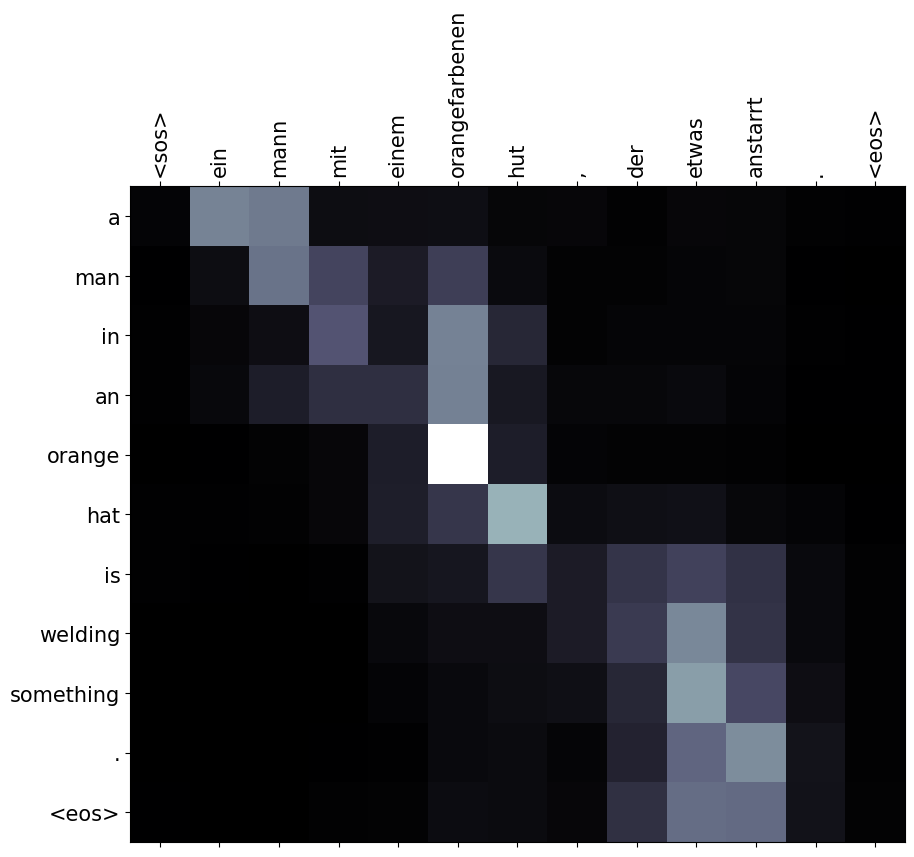

In [37]:
plot_attention(sentence_tokens, translation, attention)

In [38]:
sentence = "Ein Mann sieht sich einen Film an."

In [39]:
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [40]:
translation

['<sos>', 'a', 'man', 'is', 'looking', 'at', 'a', 'conference', '.', '<eos>']

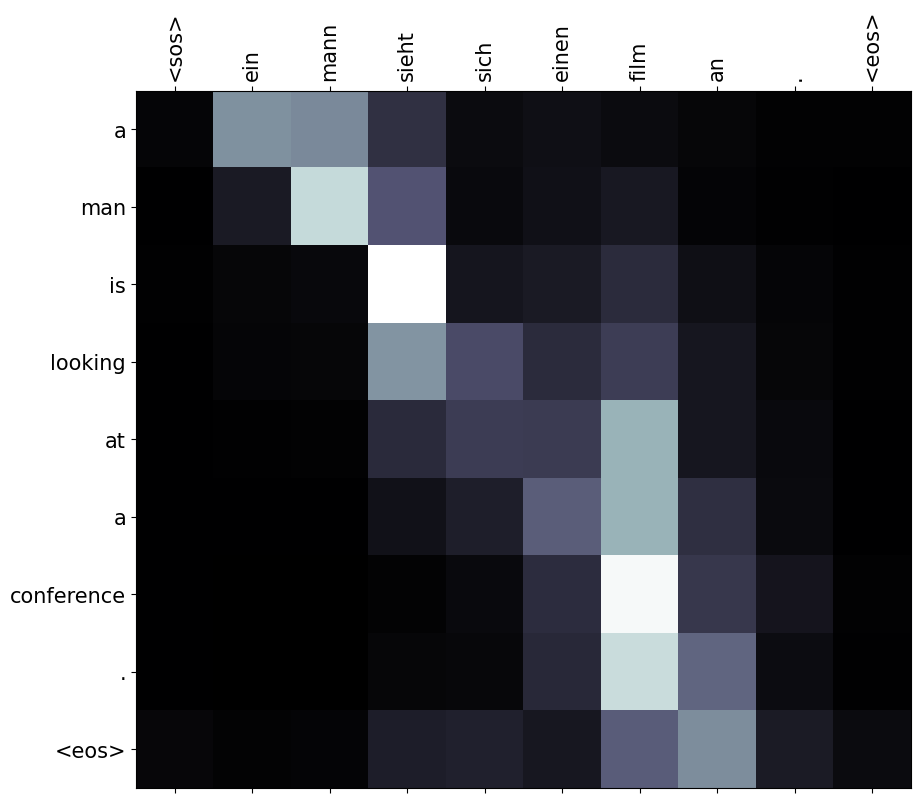

In [41]:
plot_attention(sentence_tokens, translation, attention)

In [42]:
translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )[0]
    for example in tqdm.tqdm(test_data)
]

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:19<00:00, 50.08it/s]


In [43]:
bleu = evaluate.load("bleu")

In [44]:
predictions = [" ".join(translation[1:-1]) for translation in translations]

references = [[example["en"]] for example in test_data]

In [45]:
def get_tokenizer_fn(nlp, lower):
    def tokenizer_fn(s):
        tokens = [token.text for token in nlp.tokenizer(s)]
        if lower:
            tokens = [token.lower() for token in tokens]
        return tokens

    return tokenizer_fn

In [46]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)

In [47]:
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)

In [48]:
results

{'bleu': 0.2583046682746609,
 'precisions': [0.5782342342342343,
  0.333126213592233,
  0.19528421052631578,
  0.1183448275862069],
 'brevity_penalty': 1.0,
 'length_ratio': 1.0625670087302803,
 'translation_length': 13875,
 'reference_length': 13058}

# Flaw Search
## Test Large Dataset
**NOTE: The following was copied from my earlier attempt to train on the larger data. This applies for translation testing aas well. Training was abandoned due to hardware limitations and it can be assumed that it may take at least 5 hours to train 1 epoch. Translation testing can take between 15-40 hours.**

<s>
The new dataset has 4592289 training entries. Training on this many entries requires a GPU that allows PyTorch to allocate GBs worth of data in cuda. A `OutOfMemoryError: CUDA out of memory. Tried to allocate <> GiB. GPU` error might/will occur if it cannot allocate the space while training at different epochs. Note that the memory allocation error will be less than your GPUs actual memory. This is the **additional** memory it's trying to allocate, meaning it's likely PyTorch was already utilizing all `x` GB of GPU memory before it ran out of space.

Alternatively, the (adapted) code can be modified to use on multiple GPUs. Please specify below for `training_percentage` to limit the percentage of the full training data to use. If memory is still an issue, adjust teh `batch_size`. Use `torch.cuda.memory_summary(device=None, abbreviated=False)` to see GPU allocation.

For this modified training, a `training_percentage=0.007` will be used alongside a `batch_size=128` such that it's slightly more data than the original implementation. The other reasoning is due to hardware limitations.
</s>

**NOTE: Cropping occurs in the converted dataset, process of converting still iterates through all <s>4592289</s> rows**

In [247]:
# Load new larger de-en dataset
tmp_dataset = datasets.load_dataset("wmt/wmt_t2t") # https://huggingface.co/datasets/wmt/wmt_t2t

# #### MODIFY THIS ACCORDINGLY
large_dataset_percentage = 0.001   # Set to 1.0 for full dataset
# ############################

# Convert dataset to match original schema
large_dataset = None
ens = []
des = []
for subset_name, subset in tmp_dataset.items():
    # Generate random index selection to use in cropped data
    crop_sz = max(int(large_dataset_percentage * subset.shape[0]), 1)
    cropped_random_ids = sample(range(0, subset.shape[0]), crop_sz) if int(large_dataset_percentage) != 1 else []   # If 1.0 -> no crop, don't waste time generating
    cropped_random_ids.sort()   # For random selection performance boost later

    idx_selection_idx = 0 
    selected_indx = cropped_random_ids[idx_selection_idx] if len(cropped_random_ids) != 0 else None
    for i, row in enumerate(tqdm.tqdm(subset, desc=f'Randomly appending {crop_sz} "{subset_name}" data')):   
        # Append en and de sentences. Accessing 'translation' here to skip unpacking step that occurs when iterating through subset['translation']
        if i == selected_indx or selected_indx == None:
            ens.append(row['translation']['en'])
            des.append(row['translation']['de'])
            
            # Update with next crop selected idx if not None (which is no crop)
            if selected_indx != None:
                idx_selection_idx += 1
                selected_indx = cropped_random_ids[idx_selection_idx if idx_selection_idx < crop_sz else 0]

Randomly appending 3 "test" data: 100%|██████████████████████████████████████████| 3003/3003 [00:00<00:00, 58150.41it/s]


In [248]:
large_dataset = datasets.Dataset(Table.from_arrays([pa_array(ens), pa_array(des)], names=['en', 'de']))
large_dataset

Dataset({
    features: ['en', 'de'],
    num_rows: 4598
})

In [249]:
# Tokenize Stress Data
fn_kwargs = {
    "en_nlp": en_nlp,
    "de_nlp": de_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}
large_data = large_dataset.map(tokenize_example, fn_kwargs=fn_kwargs)

# Get Token IDS for Stress Data
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}
large_data = large_data.map(numericalize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/4598 [00:00<?, ? examples/s]

Map:   0%|          | 0/4598 [00:00<?, ? examples/s]

In [250]:
large_data = large_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [251]:
model.load_state_dict(torch.load("tut3-model.pt"))

large_translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
        max_output_length=int(len(example['de_tokens']) * 1.5)
    )
    for example in tqdm.tqdm(large_data)
]

100%|███████████████████████████████████████████████████████████████████████████████| 4598/4598 [02:04<00:00, 36.90it/s]


In [252]:
bleu = evaluate.load("bleu")
predictions = [" ".join(translation[0][1:-1]) for translation in large_translations]
references = [[example["en"]] for example in large_data]

In [253]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)
results

{'bleu': 0.000654839907446413,
 'precisions': [0.059156248171480956,
  0.0020799457318715522,
  0.0001429388221841052,
  1.0455329604265775e-05],
 'brevity_penalty': 1.0,
 'length_ratio': 1.718110684784612,
 'translation_length': 205084,
 'reference_length': 119366}

#### Analysis

In [254]:
class Potential_Good_Translations:
    def __init__(self):
        self.results = []
        self.ens = []
        self.wcs = []
        self.uniques = []

    def add_items(self, result, en, wc, unique):
        self.results.append(result)
        self.ens.append(en)
        self.wcs.append(wc)
        self.uniques.append(unique)

    def make_dataframe(self):
        tmp_translations = []
        tmp_sent_tokens = []
        tmp_attentions = []
        
        for result in self.results:
            tmp_translations.append(result[0])
            tmp_sent_tokens.append(result[1])
            tmp_attentions.append(result[2])

        return pd.DataFrame({'translations': tmp_translations, 'sent_tokens': tmp_sent_tokens, 'en': self.ens,
                             'word_count': self.wcs, 'unique_words': self.uniques, 'attentions': tmp_attentions})

In [255]:
from collections import Counter

large_dataset_goods = Potential_Good_Translations()
for result, example in zip(large_translations, large_data):
    translation, sentence_tokens, attention = result
    unk_count = translation.count('<unk>')
    if unk_count / (len(translation) - 2) < 0.5:
        large_dataset_goods.add_items(result, example['en'], len(translation) - 2 - unk_count, len(Counter(translation).keys()) - 2)

In [256]:
large_dataframe = large_dataset_goods.make_dataframe()
# large_dataframe

In [257]:
large_dataframe_sorted_wc = large_dataframe.sort_values(by='word_count', ascending=False)
large_dataframe_sorted_wc.head()

,translations,sent_tokens,en,word_count,unique_words,attentions
617,"[<sos>, <unk>, (, (, (, (, (, (, (, (, (, (, (...","[<sos>, van, dyke, (, 176, ), w., s., van, dyk...",Gurley Building (1070) W. & L. E. Gurley Build...,185,2,"[[[tensor(0.0041), tensor(0.4134), tensor(0.03..."
514,"[<sos>, <unk>, <unk>, <unk>, <unk>, (, <unk>, ...","[<sos>, madyan, guesthouse, doppelzimmer, (, l...",Madyan Guesthouse Double rooms (deluxe or simp...,65,3,"[[[tensor(0.0027), tensor(0.7436), tensor(0.03..."
257,"[<sos>, lebron, <unk>, <unk>, <unk>, <unk>, ,,...","[<sos>, nach, der, tagesordnung, folgt, die, m...",The next item is the oral questions by Mrs Ban...,45,8,"[[[tensor(0.0032), tensor(0.2989), tensor(0.00..."
357,"[<sos>, the, <unk>, <unk>, <unk>, <unk>, <unk>...","[<sos>, der, sql, manager, for, mysql, eignet,...",It works with any MySQL versions from 3.23 to ...,44,3,"[[[tensor(0.0111), tensor(0.5127), tensor(0.02..."
384,"[<sos>, the, <unk>, <unk>, <unk>, <unk>, <unk>...","[<sos>, die, feria, de, sevilla, ist, ein, mus...",The Seville Fair is a musical show with Sevill...,43,5,"[[[tensor(0.0069), tensor(0.3395), tensor(0.01..."


DE: <sos> van dyke ( 176 ) w. s. van dyke ( 177 ) w. sauer orgelbau frankfurt ( oder ) ( 178 ) w. somerset maugham ( 179 ) w. spindler ( 180 ) w. stanley jevons ( 181 ) w. th . winkler ( 182 ) w. thad cochran ( 183 ) w. v. o. quine ( 184 ) w. v. quine ( 185 ) w. w. bartley ( 186 ) w. w. grainger ( 187 ) w. w. jacobs ( 188 ) w. w. rouse ball ( 189 ) w. w. sawyer ( 190 ) w. w. shols ( 191 ) w. willard wirtz ( 192 ) w. wolodarski ( 193 ) w. – ein missverstandenes leben ( 194 ) w.a.s.t.e . <eos>
EN: <sos> Gurley Building (1070) W. & L. E. Gurley Building (1071) W. & R. Chambers (1072) W. & R. Chambers, Publishers (1073) W. & R. Chambers Publishers (1074) W. & S. Jones (1075) W. (2008 film) (1076) W. (Pussyfoot) Johnson (1077) W. (film) (1078) W. (movie) (1079) W. A.C. Bennett (1080) W. A. Albizkij (1081) W. A. B. Coolidge (1082) W. A. Bolin (1083) W. A. Bolin AB (1084) W. A. Boyle (1085) W. A. C. Bennett (1086) W. A. C. Bennett Dam (1087) W. A. Cann (1088) W. A. <eos>
TR: <sos> <unk> ( ( (

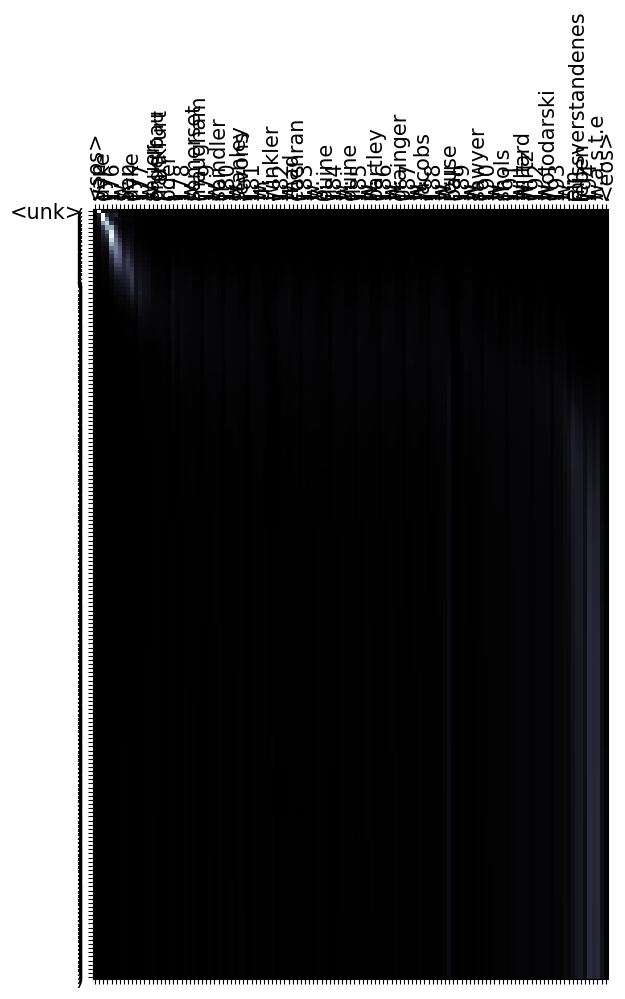

DE: <sos> madyan guesthouse doppelzimmer ( luxuriös , einfach ) , einzelzimmer , schlafraum ; eigene küche , halbpension , vollpension ; gemeinsames badezimmer , 24h heisses wasser ; internet ; wäscherei ; touristeninformation und organisation von aktivitäten ; bücheraustausch ; sicherheit , gemütlichkeit und beste aussicht ! <eos>
EN: <sos> Madyan Guesthouse Double rooms (deluxe or simple), single room, dormitory; private kitchen, half-pension, full-pension; shared bathroom, 24h hot water; internet access; laundry; tourist information and tours; free book-exchange; security, convenience and nice panoramic views! <eos>
TR: <sos> <unk> <unk> <unk> <unk> ( <unk> , , , , , , , , , , , , , and , and , and , and , and <unk> and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and


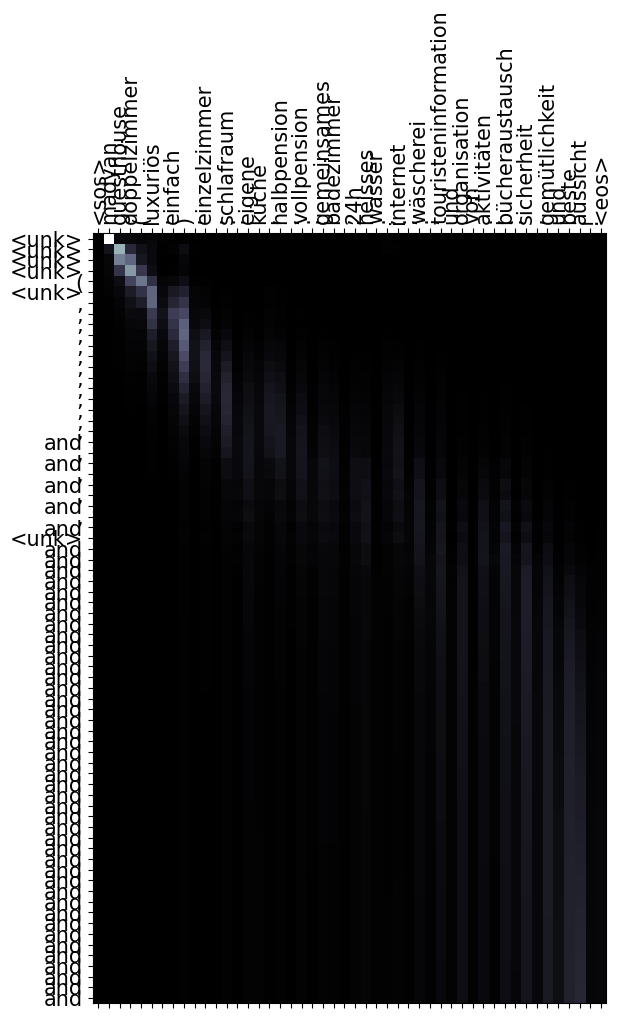

DE: <sos> nach der tagesordnung folgt die mündliche anfrage an den rat ( b4 - 0671 / 96 - 0085 / 96 ) und an die kommission ( b4 - 0672 / 96 - 0086 / 96 ) von frau banotti , frau green , den herren martens , de vries , newman , frau ahern , frau bennasar tous , herrn bertens , herrn bowe , frau cederschiöld , herrn christodoulou , herrn k. collins , frau crawley , den herren crowley , cushnahan , dimitrakopoulos , frau fouqué , den herren gahrton , gillis , harrison , hendrick , kellett-bowman , killilea , frau kinnock , den herren könig , lambrias , mccartin , frau mcintosh , frau mckenna , herrn mcmillan-scott , frau miranda de lage , den herren perry , rack , rehn , rothley , rübig , frau schmidbauer , sowie den herren stenmarck , tannert und van dijk über kindesentführungen in den mitgliedstaaten . <eos>
EN: <sos> The next item is the oral questions by Mrs Banotti, Mrs Green, Mr Martens, Mr De Vries, Mr Newman, Mrs Ahern, Mrs Bennasar Tous, Mr Bertens, Mr Bowe, Mrs Cederschiöld, Mr

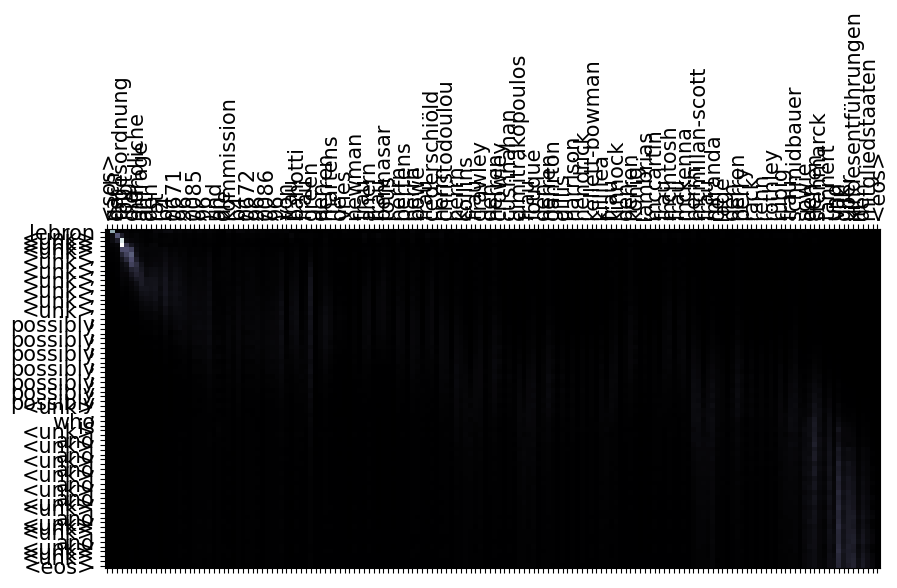

DE: <sos> der sql manager for mysql eignet sich für alle mysql versionen von 3.23 bis neuste und unterstützt alle relevanten features , einschließlich der mysql-trigger , sichten , gespeicherten prozeduren und funktionen , innodb fremdschlüssel , unicode-daten und viele weitere . <eos>
EN: <sos> It works with any MySQL versions from 3.23 to the newest one and supports all of the latest features including MySQL triggers, views, stored procedures and functions, InnoDB foreign keys, Unicode data and so on. <eos>
TR: <sos> the <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> , and <unk> <unk> , and <unk> , and <unk> , and <unk> and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and


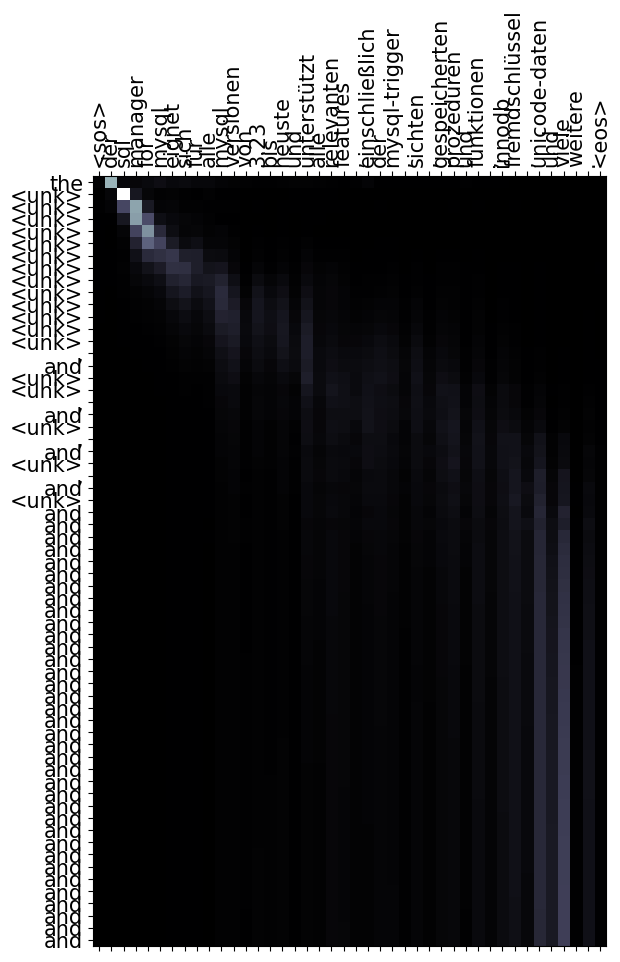

DE: <sos> die feria de sevilla ist ein musikalisches spektakel , mit den sevillanas als wichtigster musik ; es ist eine spektakel des lichts , mit mehr als 400 000 glühbirnen ; mit lampions ; mit den typischen rüschenkleidern ; mit stierkampf und natürlich mit fussball , denn die clubs betis und sevilla sind an allen ecken und enden präsent . <eos>
EN: <sos> The Seville Fair is a musical show with Sevillana music as the main music. It is a beautiful light show with more than 400,000 light bulbs, sevillana dresses, bullfights, and of course soccer, since Betis and Seville are very present in these corners. <eos>
TR: <sos> the <unk> <unk> <unk> <unk> <unk> , <unk> , <unk> , <unk> , , and <unk> , and , and , and <unk> , and <unk> , and <unk> , and <unk> and <unk> and and <unk> and and <unk> and and <unk> and and <unk> and and <unk> and and <unk> and and <unk> and and <unk> and and <unk> and and <unk> and and <unk> . <eos>


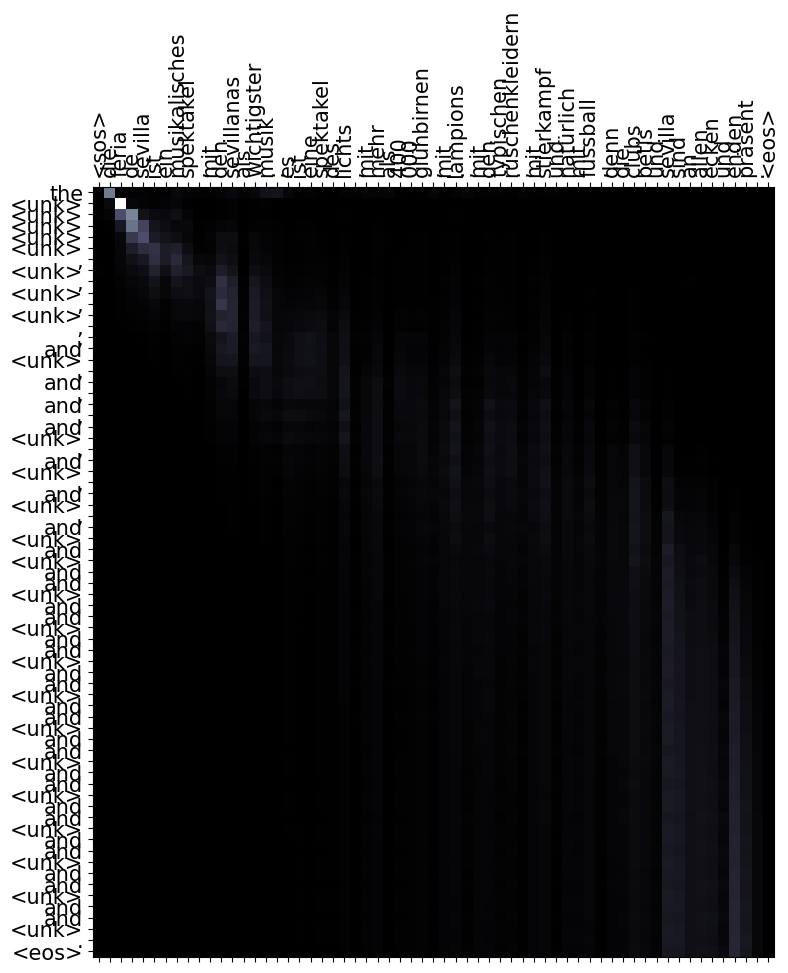

In [258]:
for _, row in large_dataframe_sorted_wc.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

In [259]:
large_dataframe_sorted_unique = large_dataframe.sort_values(by='unique_words', ascending=False)
large_dataframe_sorted_unique.head()

,translations,sent_tokens,en,word_count,unique_words,attentions
322,"[<sos>, there, many, many, many, people, are, ...","[<sos>, auch, viele, auswertige, leute, machen...","The idea is quite befitting especially now, in...",21,16,"[[[tensor(0.0029), tensor(0.9110), tensor(0.01..."
425,"[<sos>, lebron, james, ,, <unk>, <unk>, ,, <un...","[<sos>, e, zu, den, partnern, ,, die, bereits,...",E to the partners that already possess mine to...,34,14,"[[[tensor(0.0041), tensor(0.8231), tensor(0.02..."
342,"[<sos>, she, is, a, man, who, is, her, mother,...","[<sos>, sie, sucht, einen, mann, ,, der, sie, ...",They like men who make them laugh and feel hap...,19,14,"[[[tensor(0.0057), tensor(0.8362), tensor(0.02..."
727,"[<sos>, some, people, are, as, they, are, gath...","[<sos>, einige, fans, ,, als, sie, hinter, ihm...","Some Fans as they passed behind him, they want...",17,13,"[[[tensor(0.0288), tensor(0.8007), tensor(0.06..."
472,"[<sos>, lebron, <unk>, <unk>, <unk>, ,, one, t...","[<sos>, um, gut, chinlone, zu, spielen, ,, mus...","To play chinlone well, the whole team must be ...",20,13,"[[[tensor(0.0072), tensor(0.6954), tensor(0.04..."


DE: <sos> auch viele auswertige leute machen an dieser lotterie mit , was sich lohnt , vorallem in der ferienzeit , wo mehrere leute einer gemeinschaft sich einen preis im wert von millionen teilen . <eos>
EN: <sos> The idea is quite befitting especially now, in holiday season where many people in one community share a grand prize worth millions. <eos>
TR: <sos> there many many many people are gathered on what appears to be <unk> , <unk> , and <unk> , <unk> , <unk> , <unk> in a <unk> . <eos>


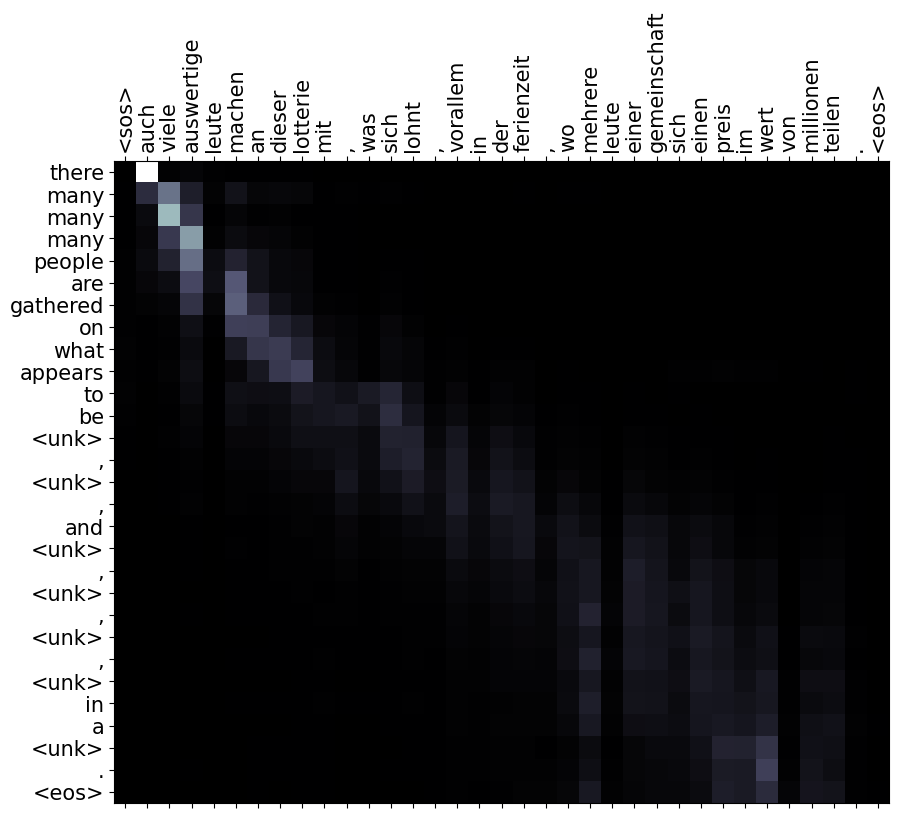

DE: <sos> e zu den partnern , die bereits meine besitzen zur fahne es ist allein , zu q i zu mir i platz zu informieren ! <eos>
EN: <sos> E to the partners that already possess mine to banner it is alone to inform to q I to me I place! <eos>
TR: <sos> lebron james , <unk> <unk> , <unk> , the the , , , , the , , , , , , , , and the , and , who is ready to be the same time . <eos>


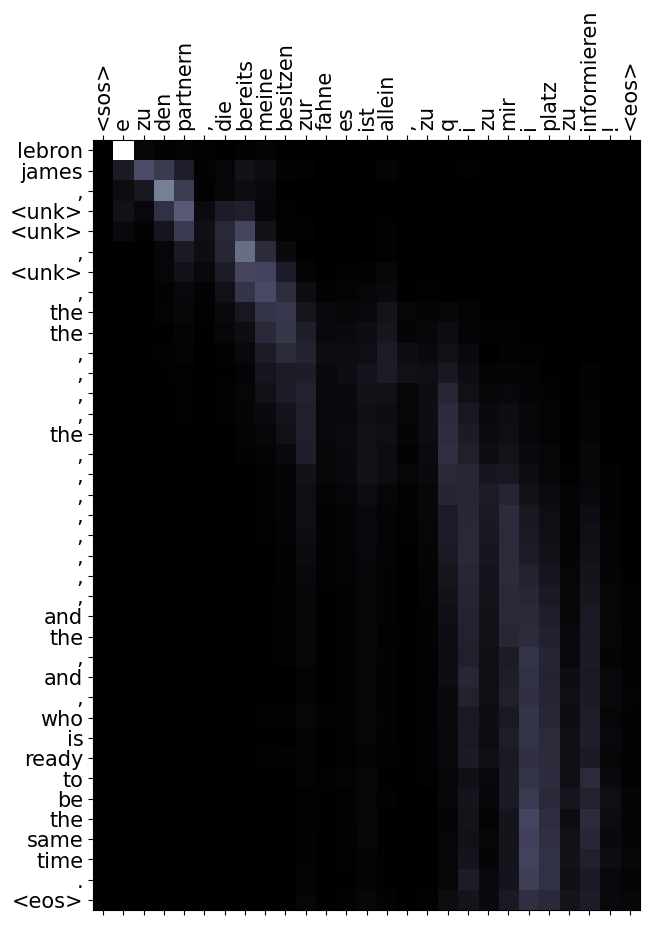

DE: <sos> sie sucht einen mann , der sie zum lachen bringt und glücklich macht , ohne große macho-allüren an den tag zu legen . tipp : machen sie ihr keine eifersuchtsszenen . <eos>
EN: <sos> They like men who make them laugh and feel happy, but who don't annoy them with manly attitudes. <eos>
TR: <sos> she is a man who is her mother and her , and her <unk> to her <unk> on the the . <eos>


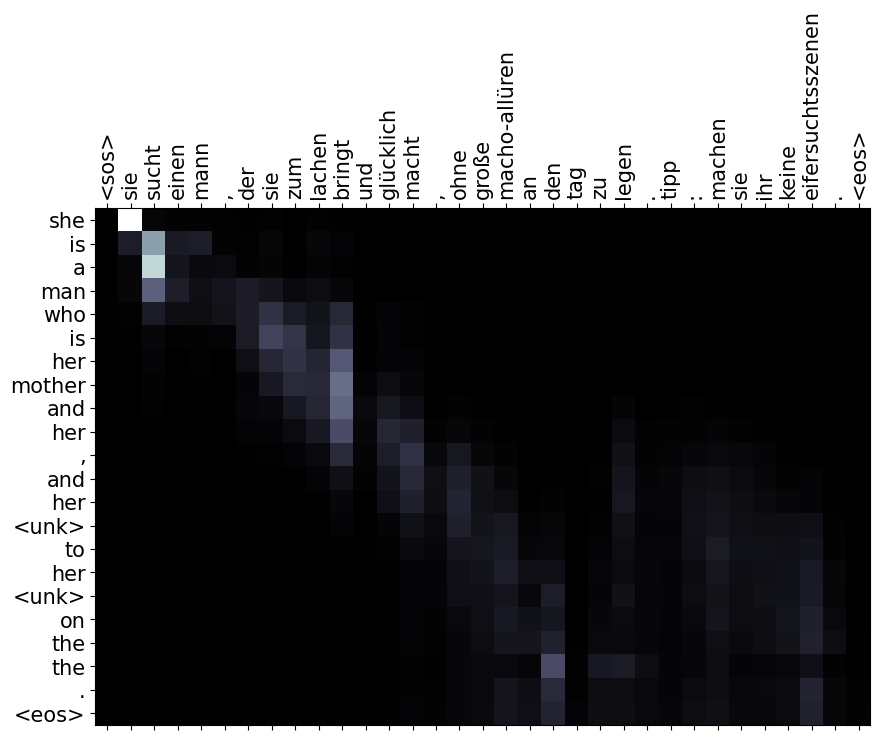

DE: <sos> einige fans , als sie hinter ihm vorbei , sie wollten ein autogramm , und sie waren ein wenig auf die schulter . <eos>
EN: <sos> Some Fans as they passed behind him, they wanted an autograph and they were a touch on his shoulder. <eos>
TR: <sos> some people are as they are gathered and a a <unk> , holding a a on a . <eos>


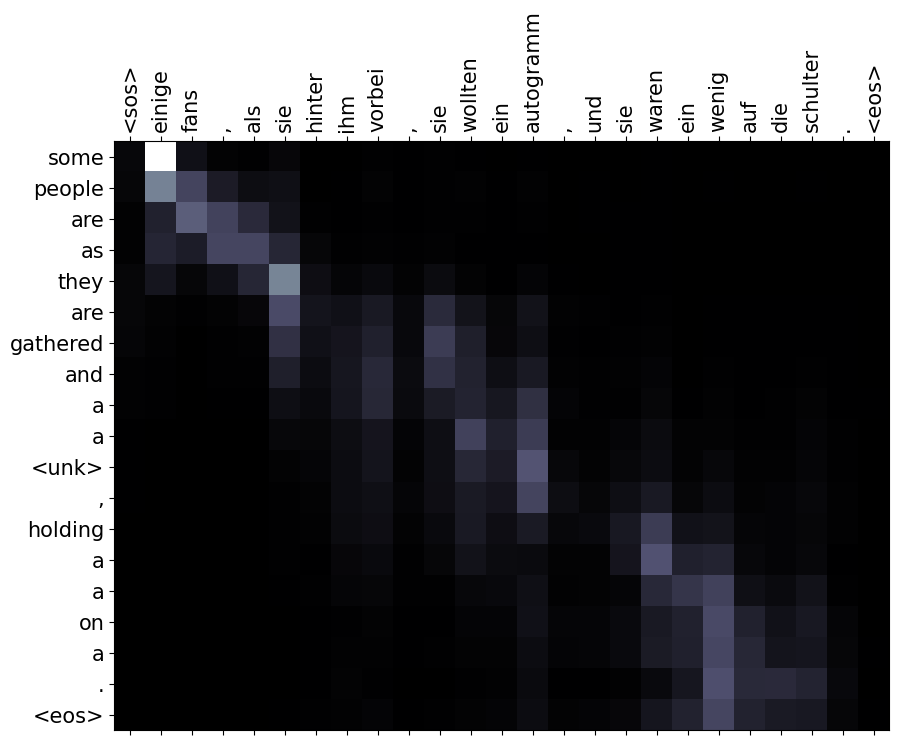

DE: <sos> um gut chinlone zu spielen , muss das gesamte team immer aufmerksam sein - wenn jemand abgelenkt ist , fällt der ball zu boden . <eos>
EN: <sos> To play chinlone well, the whole team must be absolutely in the moment – their minds cannot wander or the ball will drop. <eos>
TR: <sos> lebron <unk> <unk> <unk> , one team is the the team , as she is to her to to the the ball . <eos>


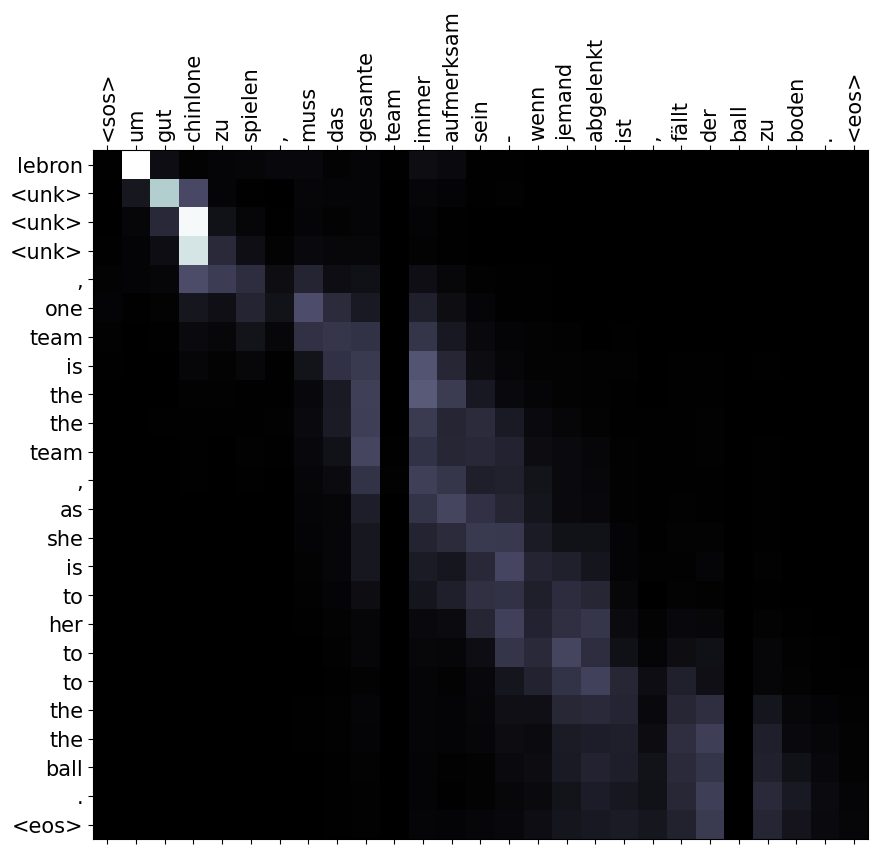

In [260]:
for _, row in large_dataframe_sorted_unique.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

## Complexity/Stress Test Dataset

In [261]:
# Load complex de-en dataset. Dataset from https://www.manythings.org/anki/
complex_dataset = pd.read_csv('deu-eng/deu.txt', names=['en', 'de', 'ack'], sep='\t', header=None).dropna()
complex_dataset['word_count'] = complex_dataset['de'].apply(lambda x: (len(x.split())) + 1)
complex_dataset['complexity'] = complex_dataset['de'].apply(lambda x: (len(x.split()) // 25) + 1)
stress_eval_dataset = datasets.Dataset(Table.from_pandas(complex_dataset[['en', 'de', 'complexity']]))
stress_eval_dataset

Dataset({
    features: ['en', 'de', 'complexity'],
    num_rows: 277891
})

In [262]:
# Tokenize Stress Data
fn_kwargs = {
    "en_nlp": en_nlp,
    "de_nlp": de_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}
stress_data = stress_eval_dataset.map(tokenize_example, fn_kwargs=fn_kwargs)

# Get Token IDS for Stress Data
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}
stress_data = stress_data.map(numericalize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/277891 [00:00<?, ? examples/s]

Map:   0%|          | 0/277891 [00:00<?, ? examples/s]

In [263]:
stress_data = stress_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [264]:
model.load_state_dict(torch.load("tut3-model.pt"))

stress_translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
        max_output_length=int(len(example['de_tokens']) * 1.5)
    )
    for example in tqdm.tqdm(stress_data)
]

100%|█████████████████████████████████████████████████████████████████████████| 277891/277891 [1:06:28<00:00, 69.68it/s]


In [265]:
bleu = evaluate.load("bleu")
predictions = [" ".join(translation[0][1:-1]) for translation in stress_translations]
references = [[example["en"]] for example in stress_data]

In [266]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)
results

{'bleu': 0.006854207300350306,
 'precisions': [0.10607822878100977,
  0.01094258373866966,
  0.0027093062084453086,
  0.0007018183354992763],
 'brevity_penalty': 1.0,
 'length_ratio': 2.148625304883154,
 'translation_length': 4619553,
 'reference_length': 2150004}

#### Analysis

In [267]:
class PGT_Stress(Potential_Good_Translations):
    def __init__(self):
        super().__init__()
        self.complexities = []

    def add_items(self, result, en, wc, unique, complexity):
        super().add_items(result, en, wc, unique)
        self.complexities.append(complexity)

    def make_dataframe(self):
        tmp_df = super().make_dataframe()
        tmp_df['complexities'] = self.complexities

        return tmp_df

In [268]:
stress_dataset_goods = PGT_Stress()
for result, example in zip(tqdm.tqdm(stress_translations), stress_data):
    translation, sentence_tokens, attention = result
    unk_count = translation.count('<unk>')
    if (unk_count / (len(translation) - 2) < 0.5 and np.abs(len(sentence_tokens) - len(translations) < 5)) or example['complexity'] > 1:
        stress_dataset_goods.add_items(result, example['en'], len(translation) - 2 - unk_count, 
                                       len(Counter(translation).keys()) - 2, example['complexity'])

100%|█████████████████████████████████████████████████████████████████████████| 277891/277891 [01:02<00:00, 4456.93it/s]


In [269]:
stress_dataframe = stress_dataset_goods.make_dataframe()
# stress_dataframe

In [270]:
stress_dataframe_sorted_wc = stress_dataframe.sort_values(by='word_count', ascending=False)
stress_dataframe_sorted_wc.head()

,translations,sent_tokens,en,word_count,unique_words,attentions,complexities
159672,"[<sos>, <unk>, <unk>, <unk>, to, be, <unk>, ,,...","[<sos>, tom, wälzte, sich, um, 6.30, uhr, aus,...","Tom rolled out of bed at 6:30, shuffled into t...",32,11,"[[[tensor(0.0057), tensor(0.8118), tensor(0.03...",1
159456,"[<sos>, <unk>, james, <unk>, <unk>, ,, ,, the,...","[<sos>, maria, hat, tom, dabei, erwischt, ,, w...","Mary caught Tom prying into her diary, trying ...",27,8,"[[[tensor(0.0040), tensor(0.8468), tensor(0.02...",1
159791,"[<sos>, many, <unk>, of, young, boys, are, <un...","[<sos>, viele, gepiercte, jugendliche, bleiben...",Many young people with piercings stay together...,26,15,"[[[tensor(0.0705), tensor(0.5760), tensor(0.16...",2
153300,"[<sos>, we, <unk>, to, make, <unk>, to, tell, ...","[<sos>, ich, wette, ,, ihr, werdet, mir, sagen...",I bet you're going to tell me you're too tired...,26,6,"[[[tensor(0.0010), tensor(0.9636), tensor(0.02...",1
159721,"[<sos>, here, is, a, woman, woman, to, be, a, ...","[<sos>, es, ist, schwer, eine, frau, zu, sein,...",It's hard to be a woman. One must think like a...,25,12,"[[[tensor(0.0057), tensor(0.3114), tensor(0.07...",2


DE: <sos> tom wälzte sich um 6.30 uhr aus dem bett , schlurfte in die küche und steckte zwei scheiben brot in den toaster . <eos>
EN: <sos> Tom rolled out of bed at 6:30, shuffled into the kitchen and put two slices of bread into the toaster. <eos>
TR: <sos> <unk> <unk> <unk> to be <unk> , the children , they are in the kitchen , two asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian


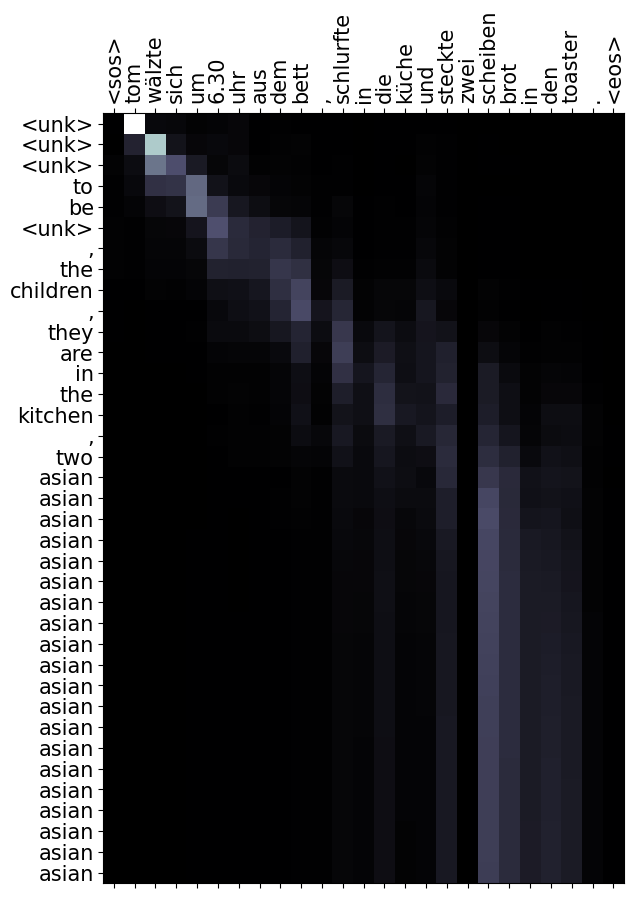

DE: <sos> maria hat tom dabei erwischt , wie er in ihrem tagebuch herumschnüffelte , um herauszufinden , ob sie sich noch mit jemand anderem traf . <eos>
EN: <sos> Mary caught Tom prying into her diary, trying to find out if she was seeing someone else. <eos>
TR: <sos> <unk> james <unk> <unk> , , the , , , in the <unk> , , , , , , , , , , , , , , , and a . <eos>


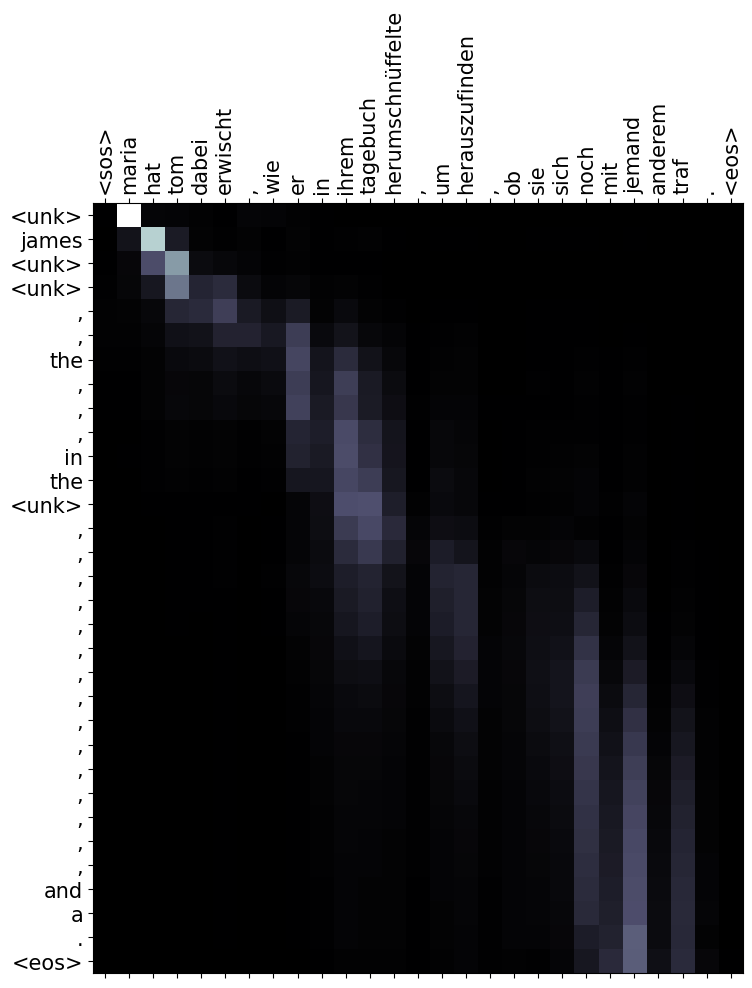

DE: <sos> viele gepiercte jugendliche bleiben mit dem partner ein leben lang zusammen – besonders wenn sich der nasenring des einen in der zahnspange des anderen verfangen hat ! <eos>
EN: <sos> Many young people with piercings stay together their whole lives, especially if one gets their nose ring stuck in the other's braces. <eos>
TR: <sos> many <unk> of young boys are <unk> to <unk> , one a , , one is holding a <unk> , one of the other , one is the other . <eos>


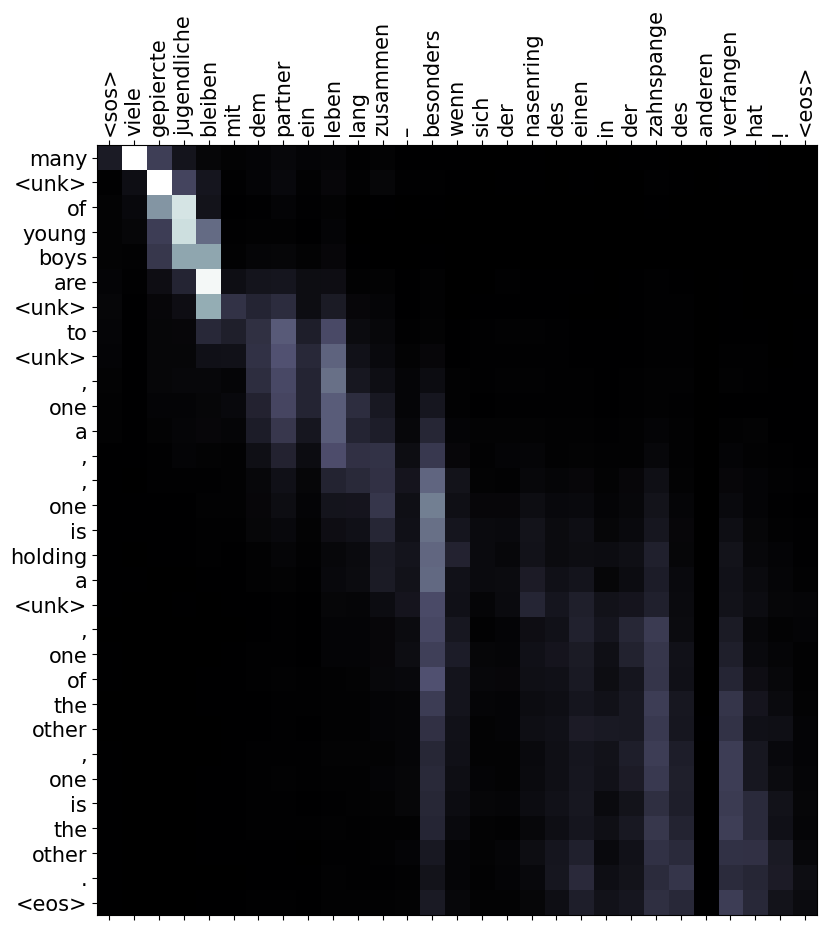

DE: <sos> ich wette , ihr werdet mir sagen , dass ihr zu müde seid , um zu helfen . <eos>
EN: <sos> I bet you're going to tell me you're too tired to help. <eos>
TR: <sos> we <unk> to make <unk> to tell to to to to to to to to to to to to to to to to to to to to . <eos>


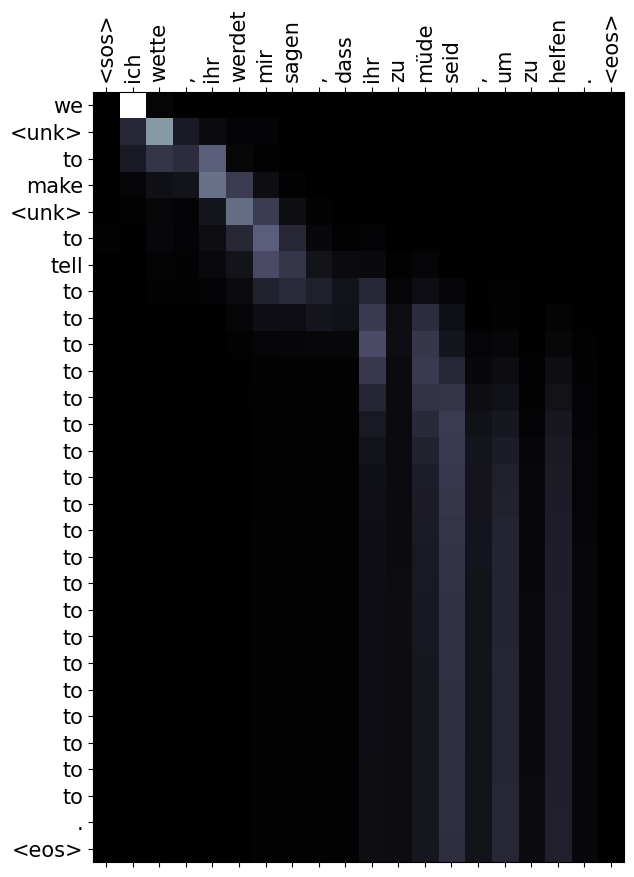

DE: <sos> es ist schwer eine frau zu sein . man muss wie ein mann denken , sich wie eine dame benehmen , wie ein mädchen aussehen und wie ein pferd arbeiten . <eos>
EN: <sos> It's hard to be a woman. One must think like a man, act like a lady, look like a girl, and work like a horse. <eos>
TR: <sos> here is a woman woman to be a man , as a woman , as a girl , and a man and a a . <eos>


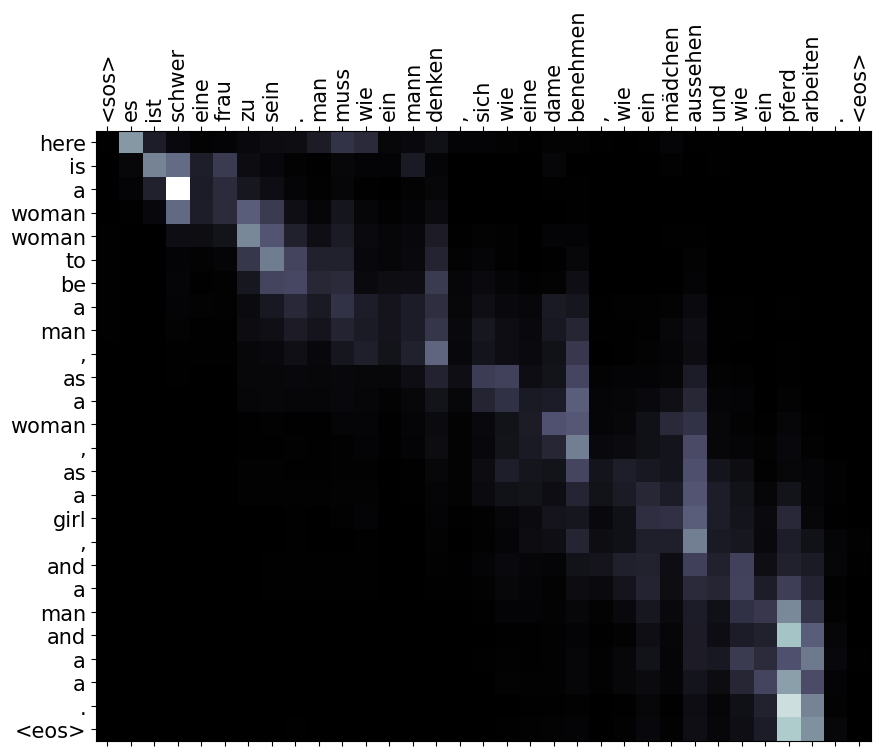

In [271]:
for _, row in stress_dataframe_sorted_wc.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

In [272]:
stress_dataframe_sorted_unique = stress_dataframe.sort_values(by='unique_words', ascending=False)
stress_dataframe_sorted_unique.head()

,translations,sent_tokens,en,word_count,unique_words,attentions,complexities
153912,"[<sos>, this, long, -, haired, <unk>, with, th...","[<sos>, wie, lange, kannst, du, mit, geschloss...",How long can you stand on one leg with your ey...,17,17,"[[[tensor(0.0025), tensor(0.9865), tensor(0.00...",1
159788,"[<sos>, a, <unk>, <unk>, is, a, group, of, peo...","[<sos>, ein, komitee, ist, eine, gruppe, von, ...",A committee is a group of people who individua...,22,16,"[[[tensor(0.0064), tensor(0.1354), tensor(0.41...",2
153504,"[<sos>, college, <unk>, you, have, what, appea...","[<sos>, vielleicht, könnt, ihr, etwas, vorschl...",Perhaps you could suggest something we can do ...,18,15,"[[[tensor(0.0016), tensor(0.9701), tensor(0.01...",1
107650,"[<sos>, a, bride, is, looking, at, the, camera...","[<sos>, hören, sie, auf, zu, reden, und, gehen...",Stop talking and get back to work.,16,15,"[[[tensor(0.0153), tensor(0.7288), tensor(0.18...",1
125808,"[<sos>, lebron, you, <unk>, what, appears, to,...","[<sos>, erzählen, sie, mir, nicht, ,, wie, ich...",Don't tell me how to raise my children.,16,15,"[[[tensor(0.0055), tensor(0.6530), tensor(0.08...",1


DE: <sos> wie lange kannst du mit geschlossenen augen auf einem bein stehen ? <eos>
EN: <sos> How long can you stand on one leg with your eyes closed? <eos>
TR: <sos> this long - haired <unk> with their eyes closed on a a stand , one of them . <eos>


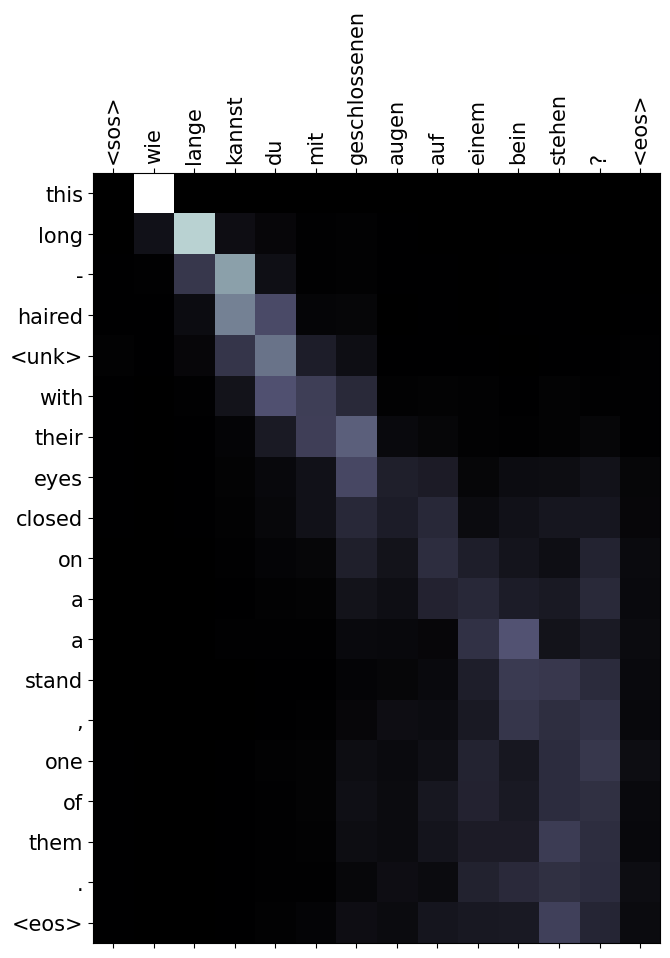

DE: <sos> ein komitee ist eine gruppe von menschen , die als einzelne nichts machen können , die aber als gruppe eine sitzung abhalten und zu der entscheidung gelangen können , dass man nichts machen kann . <eos>
EN: <sos> A committee is a group of people who individually can do nothing, but who, as a group, can meet and decide that nothing can be done. <eos>
TR: <sos> a <unk> <unk> is a group of people , as he is like the <unk> , as they are ready to the the the . <eos>


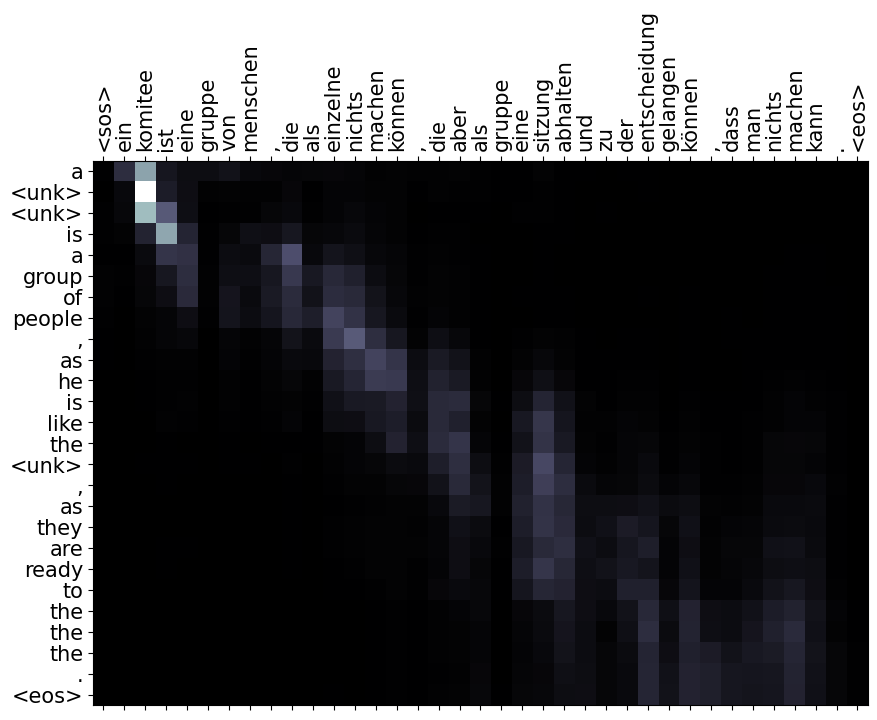

DE: <sos> vielleicht könnt ihr etwas vorschlagen , was wir morgen machen können ? <eos>
EN: <sos> Perhaps you could suggest something we can do tomorrow. <eos>
TR: <sos> college <unk> you have what appears to be what appears to be money for the peace new york . <eos>


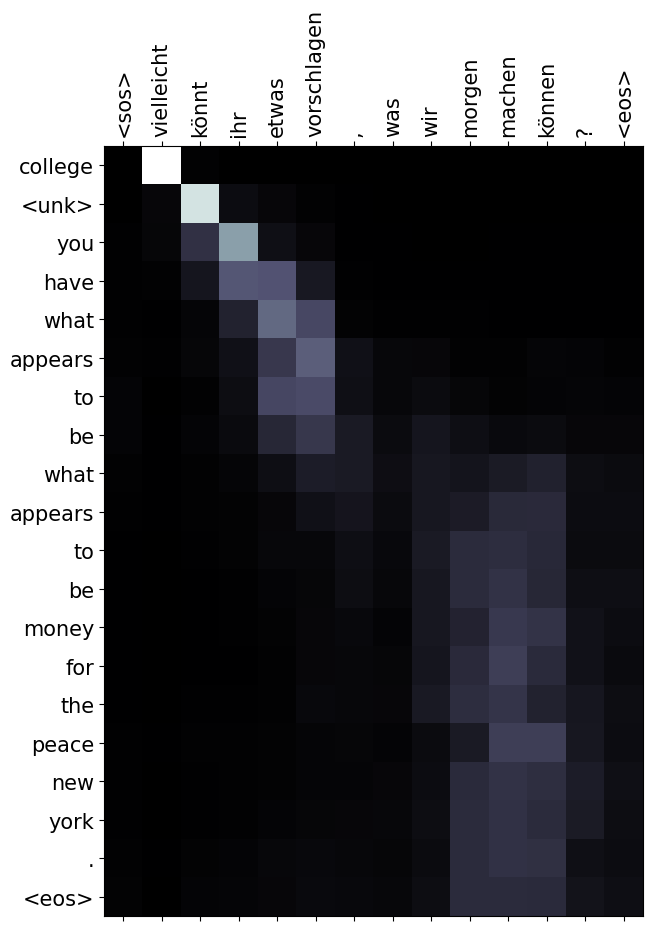

DE: <sos> hören sie auf zu reden und gehen sie zurück an die arbeit ! <eos>
EN: <sos> Stop talking and get back to work. <eos>
TR: <sos> a bride is looking at the camera , they are ready to the new york . <eos>


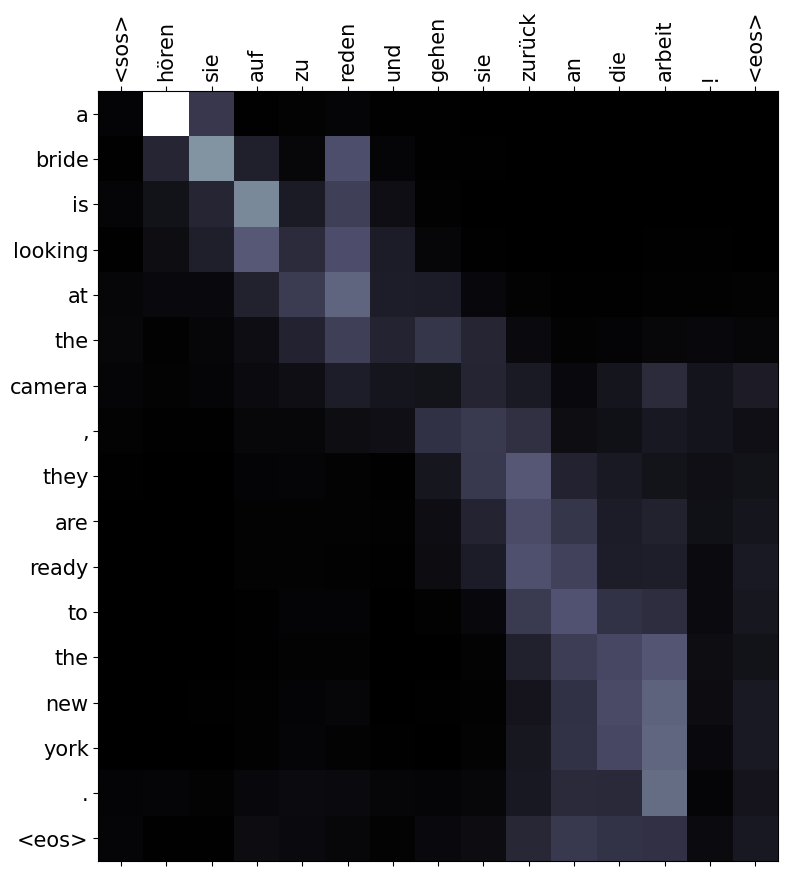

DE: <sos> erzählen sie mir nicht , wie ich meine kinder zu erziehen habe ! <eos>
EN: <sos> Don't tell me how to raise my children. <eos>
TR: <sos> lebron you <unk> what appears to be so so young children who is about to your ! <eos>


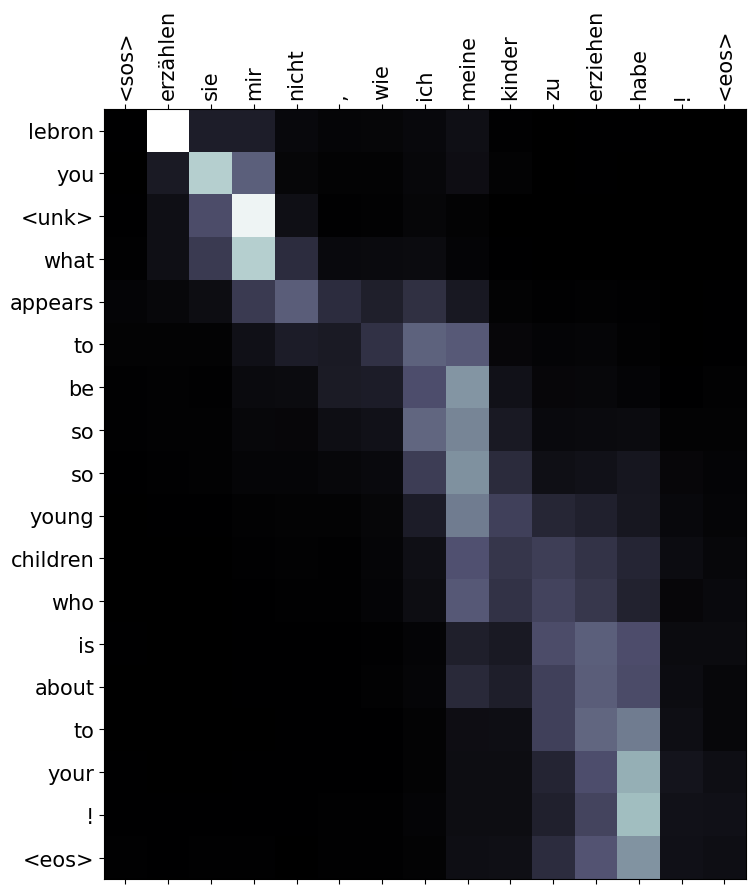

In [273]:
for _, row in stress_dataframe_sorted_unique.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

In [274]:
stress_dataframe_sorted_unique_complexities = stress_dataframe.groupby(by='complexities')
# [stress_dataframe_sorted_unique_complexities.get_group(i) for i in np.arange(1, 5)]
top_rated_of_complexities = [stress_dataframe_sorted_unique_complexities.get_group(i).sort_values(by=['word_count', 'unique_words'], 
                                                                                                  ascending=[False, False]).head(1) for i in np.arange(1, 5)]

Complexity: 1
DE: <sos> tom wälzte sich um 6.30 uhr aus dem bett , schlurfte in die küche und steckte zwei scheiben brot in den toaster . <eos>
EN: <sos> Tom rolled out of bed at 6:30, shuffled into the kitchen and put two slices of bread into the toaster. <eos>
TR: <sos> <unk> <unk> <unk> to be <unk> , the children , they are in the kitchen , two asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian


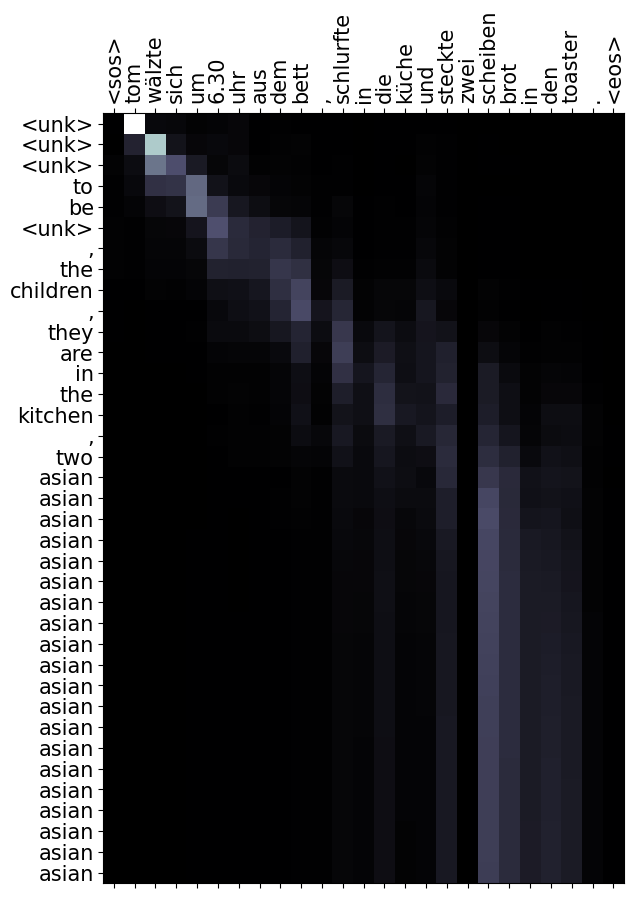

Complexity: 2
DE: <sos> viele gepiercte jugendliche bleiben mit dem partner ein leben lang zusammen – besonders wenn sich der nasenring des einen in der zahnspange des anderen verfangen hat ! <eos>
EN: <sos> Many young people with piercings stay together their whole lives, especially if one gets their nose ring stuck in the other's braces. <eos>
TR: <sos> many <unk> of young boys are <unk> to <unk> , one a , , one is holding a <unk> , one of the other , one is the other . <eos>


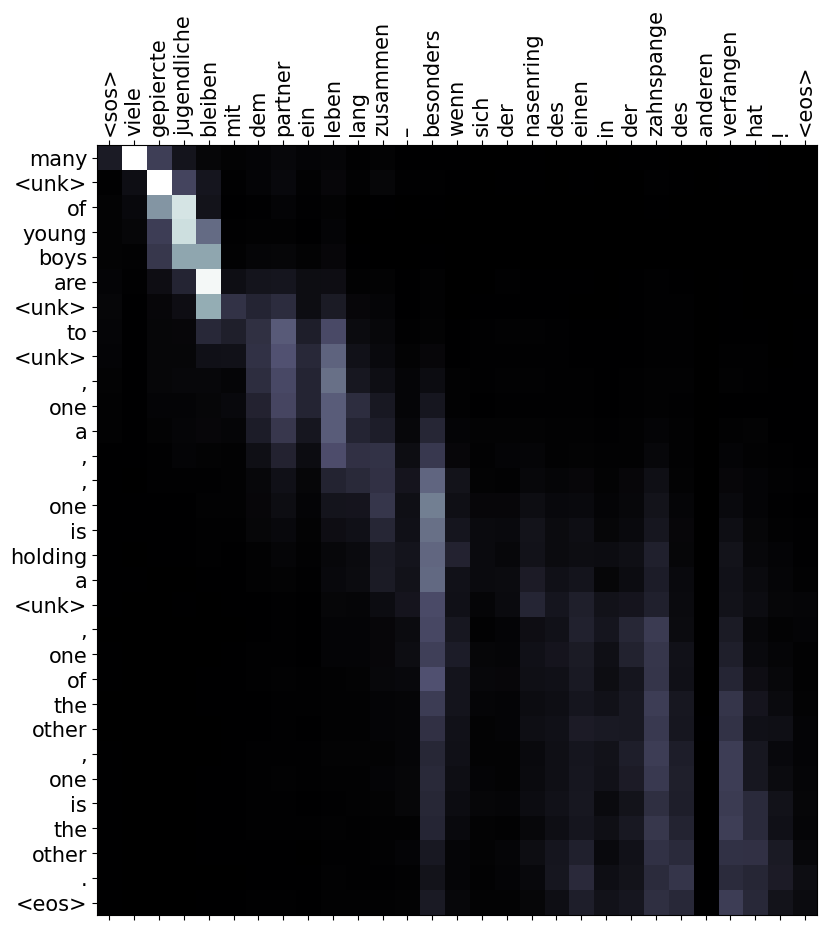

Complexity: 3
DE: <sos> wenn einem von jemandem , der nicht weiß , woher man kommt , gesagt wird , man klinge wie ein muttersprachler , dann heißt das , dass dem an der art , wie man redet , irgendwas aufgefallen sein muss , woran er erkannt hat , dass man eben keiner ist . anders ausgedrückt klingt man eher nicht wie ein muttersprachler . <eos>
EN: <sos> If someone who doesn't know your background says that you sound like a native speaker, it means they probably noticed something about your speaking that made them realize you weren't a native speaker. In other words, you don't really sound like a native speaker. <eos>
TR: <sos> a a game of what appears to be <unk> to so my <unk> so so my <unk> to see the <unk> . <eos>


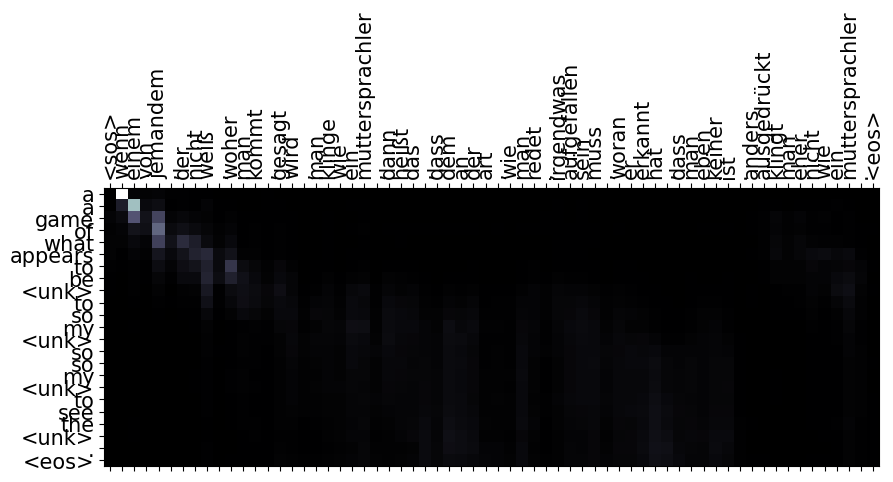

Complexity: 4
DE: <sos> ohne zweifel findet sich auf dieser welt zu jedem mann genau die richtige ehefrau und umgekehrt ; wenn man jedoch in betracht zieht , dass ein mensch nur gelegenheit hat , mit ein paar hundert anderen bekannt zu sein , von denen ihm nur ein dutzend oder weniger nahesteht , darunter höchstens ein oder zwei freunde , dann erahnt man eingedenk der millionen einwohner dieser welt   leicht , dass seit erschaffung ebenderselben wohl noch nie der richtige mann der richtigen frau begegnet ist . <eos>
EN: <sos> Doubtless there exists in this world precisely the right woman for any given man to marry and vice versa; but when you consider that a human being has the opportunity of being acquainted with only a few hundred people, and out of the few hundred that there are but a dozen or less whom he knows intimately, and out of the dozen, one or two friends at most, it will easily be seen, when we remember the number of millions who inhabit this world, that probably, since th

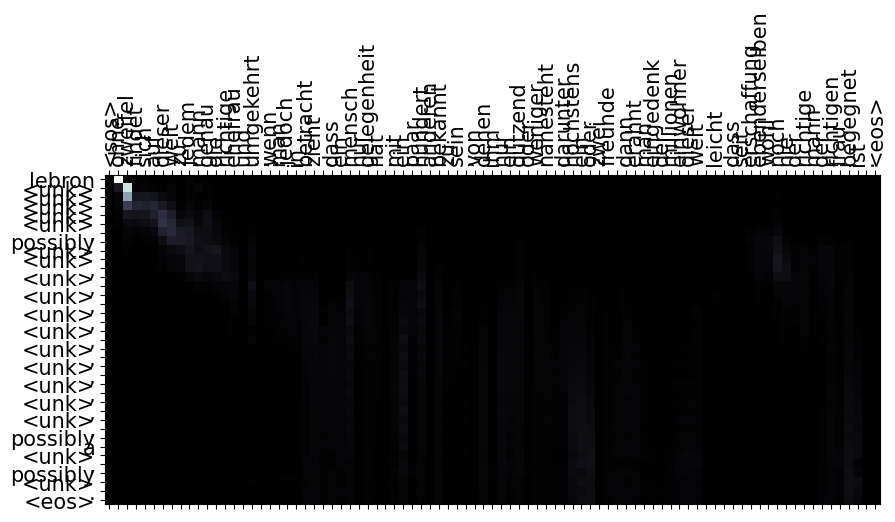

In [287]:
for top_complex in top_rated_of_complexities:
    top_row = top_complex.iloc[0]
    print('Complexity:', top_row['complexities'])
    print('DE:', ' '.join(top_row['sent_tokens']))
    print('EN: <sos>', top_row['en'], '<eos>')
    print('TR:', ' '.join(top_row['translations']))
    plot_attention(top_row['sent_tokens'], top_row['translations'], top_row['attentions'])

#### Custom Sentences

In [276]:
# sentences = ['ich möchte das kaufen', 'alles ist seinen Preis wert', 'wie viel kostet das', 'ich mochte ein bier ']
german_sents = ['Sie sahen ihn schon von weitem auf sich zukommen, denn er fiel auf.',
                'Er hatte ein ganz altes Gesicht, aber wie er ging, daran sah man, dass er erst zwanzig war.',
                'Er setzte sich mit seinem alten Gesicht zu ihnen auf die Bank. Und dann zeigte er ihnen, was er in der Hand trug.',
                '“Das war unsere Küchenuhr“, sagte er und sah sie alle der Reihe nach an, die auf der Bank in der Sonne saßen. “Ja, ich habe sie noch gefunden. Sie ist übriggeblieben.”',
                'Er hielt eine runde tellerweiße Küchenuhr vor sich hin und tupfte mit dem Finger die blaugemalten Zahlen ab.',
                '“Sie hat weiter keinen Wert,” meinte er entschuldigend, “das weiß ich auch. Und sie ist auch nicht so besonders schön. Sie ist nur wie ein Teller, so mit weißem Lack. Aber die blauen Zahlen sehen doch ganz hübsch aus, finde ich. Die Zeiger sind natürlich nur aus Blech. Und nun gehen sie auch nicht mehr. Nein. Innerlich ist sie kaputt, das steht fest. Aber sie sieht noch aus wie immer. Auch wenn sie jetzt nicht mehr geht.”',
                ''
               ] # https://learnoutlive.com/die-kuchenuhr-wolfgang-borchert/
english_sents = ['They saw him from far off, coming towards him, because he stuck out.',
                 'He had a very old face, but as he approached, it was noticeable that he was actually only about twenty.',
                 'He sat down with his old face beside them on the bench. And then he showed them what was in his hand.',
                 '“It was our kitchen clock”, he said, and looked at them all, one after the other, who sat on the bench in the sun. “Yes, I found it. It’s still here.”',
                 'He held up a round, china-white kitchen clock, and dabbed the blue painted numbers with his fingers.',
                 '“It’s worthless now”, he said apologetically, “I know that too. And it’s also not especially appealing.  It is just like a plate, with its plain white lacquer. But the blue numbers still look very pretty, I think. The hands are naturally only rough bits of tin. And now they don’t work any more, besides. No. Inside it’s broken, that’s for sure. But it still looks like it always did. Even if it doesn’t work any more.”',
                 ''
                ] # https://therhinocolumn.wordpress.com/2014/05/01/the-kitchen-clock/



In [277]:
for i, (de_sent, en_sent) in enumerate(zip(german_sents, english_sents)):
    translation, sentence_tokens, attention = translate_sentence(
        de_sent,
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )
    print('='*20, f'Translation {i+1}')
    print('DE:', de_sent)
    print('EN:', en_sent)
    print('TR:', ' '.join(translation))

==================== Translation 1
DE: Sie sahen ihn schon von weitem auf sich zukommen, denn er fiel auf.
EN: They saw him from far off, coming towards him, because he stuck out.
TR: <sos> they are <unk> <unk> <unk> <unk> <unk> <unk> <unk> . <eos>
==================== Translation 2
DE: Er hatte ein ganz altes Gesicht, aber wie er ging, daran sah man, dass er erst zwanzig war.
EN: He had a very old face, but as he approached, it was noticeable that he was actually only about twenty.
TR: <sos> this is a piece of paper , know know know <unk> <unk> <unk> . <eos>
==================== Translation 3
DE: Er setzte sich mit seinem alten Gesicht zu ihnen auf die Bank. Und dann zeigte er ihnen, was er in der Hand trug.
EN: He sat down with his old face beside them on the bench. And then he showed them what was in his hand.
TR: <sos> the <unk> <unk> with his his his his his on the the and he is his teeth . <eos>
==================== Translation 4
DE: “Das war unsere Küchenuhr“, sagte er und sah s